In [1]:
import pandas as pd
import numpy as np
import math
from pprint import pprint

# === Sample Dataset: Play Tennis ===
dataset = [
    {'Outlook':'Sunny', 'Temperature':'Hot', 'Humidity':'High', 'Wind':'Weak', 'Play':'No'},
    {'Outlook':'Sunny', 'Temperature':'Hot', 'Humidity':'High', 'Wind':'Strong', 'Play':'No'},
    {'Outlook':'Overcast', 'Temperature':'Hot', 'Humidity':'High', 'Wind':'Weak', 'Play':'Yes'},
    {'Outlook':'Rain', 'Temperature':'Mild', 'Humidity':'High', 'Wind':'Weak', 'Play':'Yes'},
    {'Outlook':'Rain', 'Temperature':'Cool', 'Humidity':'Normal', 'Wind':'Weak', 'Play':'Yes'},
    {'Outlook':'Rain', 'Temperature':'Cool', 'Humidity':'Normal', 'Wind':'Strong', 'Play':'No'},
    {'Outlook':'Overcast', 'Temperature':'Cool', 'Humidity':'Normal', 'Wind':'Strong', 'Play':'Yes'},
    {'Outlook':'Sunny', 'Temperature':'Mild', 'Humidity':'High', 'Wind':'Weak', 'Play':'No'},
    {'Outlook':'Sunny', 'Temperature':'Cool', 'Humidity':'Normal', 'Wind':'Weak', 'Play':'Yes'},
    {'Outlook':'Rain', 'Temperature':'Mild', 'Humidity':'Normal', 'Wind':'Weak', 'Play':'Yes'},
    {'Outlook':'Sunny', 'Temperature':'Mild', 'Humidity':'Normal', 'Wind':'Strong', 'Play':'Yes'},
    {'Outlook':'Overcast', 'Temperature':'Mild', 'Humidity':'High', 'Wind':'Strong', 'Play':'Yes'},
    {'Outlook':'Overcast', 'Temperature':'Hot', 'Humidity':'Normal', 'Wind':'Weak', 'Play':'Yes'},
    {'Outlook':'Rain', 'Temperature':'Mild', 'Humidity':'High', 'Wind':'Strong', 'Play':'No'}
]

# === Entropy Function ===
def entropy(target_col):
    elements, counts = np.unique(target_col, return_counts=True)
    ent = 0
    for i in range(len(elements)):
        p = counts[i]/np.sum(counts)
        ent += -p*math.log2(p)
    return ent

# === Information Gain ===
def info_gain(examples, split_attribute):
    target_col = [row['Play'] for row in examples]
    total_entropy = entropy(target_col)
    
    vals = np.unique([row[split_attribute] for row in examples])
    weighted_entropy = 0
    for v in vals:
        subset = [row for row in examples if row[split_attribute]==v]
        subset_target = [row['Play'] for row in subset]
        weighted_entropy += (len(subset)/len(examples)) * entropy(subset_target)
    
    return total_entropy - weighted_entropy

# === Recursive ID3 Decision Tree ===
def build_tree(rows, attrs):
    labels = [r['Play']  for r in rows]
    
    # Leaf: all same class or no attrs left
    if labels.count(labels[0]) == len(labels) or not attrs:
        return max(set(labels), key=labels.count)
    
    # Choose best attribute
    best = max(attrs, key=lambda a: info_gain(rows, a))
    tree = {best: {}}
    
    for v in set(r[best] for r in rows):
        subset = [r for r in rows if r[best] == v]
        tree[best][v] = build_tree(subset, [a for a in attrs if a != best])
    
    return tree


# === Build the Decision Tree ===
attributes = ['Outlook', 'Temperature', 'Humidity', 'Wind']
decision_tree = build_tree(dataset, attributes)

print("\n=== Final Decision Tree ===")
pprint(decision_tree)


=== Final Decision Tree ===
{'Outlook': {'Overcast': 'Yes',
             'Rain': {'Wind': {'Strong': 'No', 'Weak': 'Yes'}},
             'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}}}


In [4]:
import numpy as np
import pandas as pd
import math
from pprint import pprint

dataset = [
    {'Outlook':'Sunny', 'Temperature':'Hot', 'Humidity':'High', 'Wind':'Weak', 'Play':'No'},
    {'Outlook':'Sunny', 'Temperature':'Hot', 'Humidity':'High', 'Wind':'Strong', 'Play':'No'},
    {'Outlook':'Overcast', 'Temperature':'Hot', 'Humidity':'High', 'Wind':'Weak', 'Play':'Yes'},
    {'Outlook':'Rain', 'Temperature':'Mild', 'Humidity':'High', 'Wind':'Weak', 'Play':'Yes'},
    {'Outlook':'Rain', 'Temperature':'Cool', 'Humidity':'Normal', 'Wind':'Weak', 'Play':'Yes'},
    {'Outlook':'Rain', 'Temperature':'Cool', 'Humidity':'Normal', 'Wind':'Strong', 'Play':'No'},
    {'Outlook':'Overcast', 'Temperature':'Cool', 'Humidity':'Normal', 'Wind':'Strong', 'Play':'Yes'},
    {'Outlook':'Sunny', 'Temperature':'Mild', 'Humidity':'High', 'Wind':'Weak', 'Play':'No'},
    {'Outlook':'Sunny', 'Temperature':'Cool', 'Humidity':'Normal', 'Wind':'Weak', 'Play':'Yes'},
    {'Outlook':'Rain', 'Temperature':'Mild', 'Humidity':'Normal', 'Wind':'Weak', 'Play':'Yes'},
    {'Outlook':'Sunny', 'Temperature':'Mild', 'Humidity':'Normal', 'Wind':'Strong', 'Play':'Yes'},
    {'Outlook':'Overcast', 'Temperature':'Mild', 'Humidity':'High', 'Wind':'Strong', 'Play':'Yes'},
    {'Outlook':'Overcast', 'Temperature':'Hot', 'Humidity':'Normal', 'Wind':'Weak', 'Play':'Yes'},
    {'Outlook':'Rain', 'Temperature':'Mild', 'Humidity':'High', 'Wind':'Strong', 'Play':'No'}
]

def entropy (t_c):
    ele, count = np.unique(t_c, return_counts = True)
    ent = 0
    for i in range(len(ele)):
        p = count[i] / np.sum(count)
        ent += -p*math.log2(p)
    return ent


def info_g(expample, split_att):
    target_c = [row['Play'] for row in example]
    total_ent = entropy(target_c)

    vals = np.unique([row[split_att] for row in example])
    weight = 0

    for v in vals:
        subset = [row for row in example if row [split_att] == v]
        subset_target = [row['Play'] for row in subset]
        weight += (len(subset) / len(example)) * (entropy(subset_target))
    return total_ent - weight

def buid_tree(rows, attr):
    label = [r['Play'] for r in rows]
    if label.count(label[0] == len(label)) or not attr:
        return max(set(label), key=label.count)

    best = max(attr, key = lambda a: info_g(rows, a))

    tree = { best: {}}
    for v in set(r [best] for r in rows):
        subset = [r for r in rows if [best] == v]
        tree[best][v] = build_tree(subset, [a for a in attr if a != best])
    return tree

attributes = ['Outlook', 'Temperature', 'Humidity', 'Wind']
d_t = build_tree(dataset, attributes)

pprint(d_t)

{'Outlook': {'Overcast': 'Yes',
             'Rain': {'Wind': {'Strong': 'No', 'Weak': 'Yes'}},
             'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}}}


Hyperplane: x = 2

Classification Results:
[3 1] → Positive
[ 3 -1] → Positive
[6 1] → Positive
[ 6 -1] → Positive
[1 0] → Negative
[0 1] → Negative
[ 0 -1] → Negative
[-1  0] → Negative


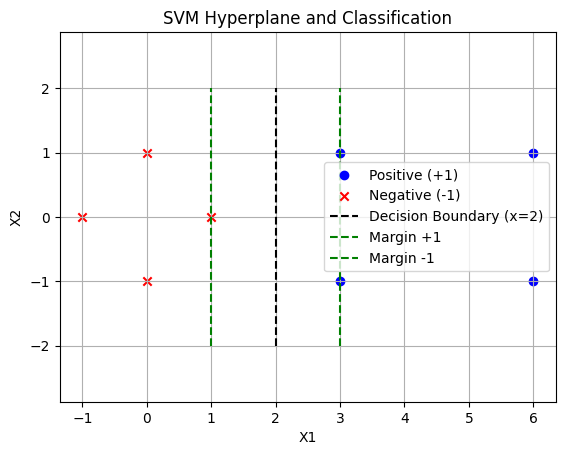

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# === Data points ===
pos = np.array([[3, 1], [3, -1], [6, 1], [6, -1]])
neg = np.array([[1, 0], [0, 1], [0, -1], [-1, 0]])

# === Hyperplane: w.x + b = 0 ===
w = np.array([1, 0])   # weight vector → separates by x-axis
b = -2                 # bias → x = 2 line

def predict(x):
    return "Positive" if np.dot(w, x) + b > 0 else "Negative"

# === Classification Output ===
print("Hyperplane: x = 2\n")
print("Classification Results:")
for p in pos:
    print(p, "→", predict(p))
for n in neg:
    print(n, "→", predict(n))

# === Visualization ===
plt.scatter(pos[:, 0], pos[:, 1], color='blue', label='Positive (+1)', marker='o')
plt.scatter(neg[:, 0], neg[:, 1], color='red', label='Negative (-1)', marker='x')

# Decision boundary and margins
plt.plot([2, 2], [-2, 2], 'k--', label='Decision Boundary (x=2)')
plt.plot([3, 3], [-2, 2], 'g--', label='Margin +1')
plt.plot([1, 1], [-2, 2], 'g--', label='Margin -1')

plt.title("SVM Hyperplane and Classification")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid(True)
plt.axis('equal')

plt.show()

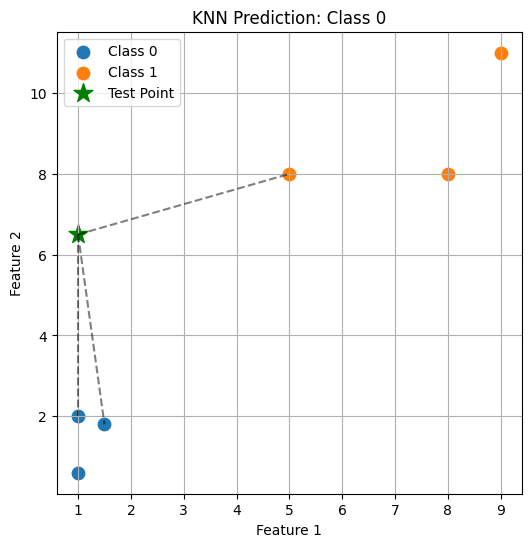

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# === Dataset ===
X = np.array([[1.0, 2.0], [1.5, 1.8], [5.0, 8.0], [8.0, 8.0], [1.0, 0.6], [9.0, 11.0]])
Y = np.array([0, 0, 1, 1, 0, 1])

# === KNN Prediction ===
def knn_predict(X_train, Y_train, test_point, k=3):
    distances = np.linalg.norm(X_train - test_point, axis=1)
    k_indices = distances.argsort()[:k]
    k_labels = Y_train[k_indices]
    prediction = Counter(k_labels).most_common(1)[0][0]
    return prediction, k_indices

# Test point
test_point = np.array([1.0, 6.5])
prediction, neighbors = knn_predict(X, Y, test_point, k=3)

# === Simple Visualization ===
plt.figure(figsize=(6,6))

# Plot dataset points
for label in np.unique(Y):
    plt.scatter(X[Y==label,0], X[Y==label,1], label=f'Class {label}', s=80)

# Plot test point
plt.scatter(test_point[0], test_point[1], c='green', marker='*', s=200, label='Test Point')

# Draw lines to nearest neighbors
for i in neighbors:
    plt.plot([test_point[0], X[i,0]], [test_point[1], X[i,1]], 'k--', alpha=0.5)

plt.title(f"KNN Prediction: Class {prediction}")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()


Test Point: Age=30, Income=45K
Predicted Class: Yes


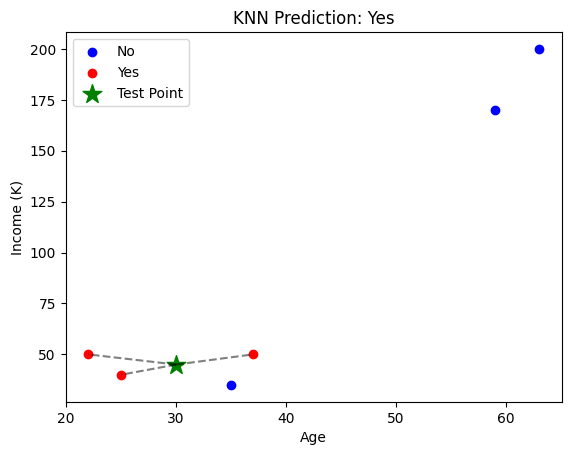

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# === Dataset ===
age = np.array([35, 22, 63, 59, 25, 37])
income = np.array([35, 50, 200, 170, 40, 50])
classes = np.array([0, 1, 0, 0, 1, 1])  # 0=No, 1=Yes

X = np.column_stack((age, income))
Y = classes

# === KNN function ===
def knn_predict(X_train, Y_train, test_point, k=3):
    distances = np.linalg.norm(X_train - test_point, axis=1)
    k_indices = distances.argsort()[:k]
    k_labels = Y_train[k_indices]
    prediction = Counter(k_labels).most_common(1)[0][0]
    return prediction

# Test point
test_point = np.array([30, 45])
prediction = knn_predict(X, Y, test_point, k=3)

print(f"Test Point: Age={test_point[0]}, Income={test_point[1]}K")
print(f"Predicted Class: {'Yes' if prediction==1 else 'No'}")

# === Simple Visualization ===
plt.scatter(X[Y==0,0], X[Y==0,1], color='blue', label='No')
plt.scatter(X[Y==1,0], X[Y==1,1], color='red', label='Yes')
plt.scatter(test_point[0], test_point[1], color='green', marker='*', s=200, label='Test Point')
for i in neighbors:
    plt.plot([test_point[0], X[i,0]], [test_point[1], X[i,1]], 'k--', alpha=0.5)
plt.xlabel("Age")
plt.ylabel("Income (K)")
plt.title(f"KNN Prediction: {'Yes' if prediction==1 else 'No'}")
plt.legend()
plt.show()

slope b0: 2.400
coefficient b1: 0.400
mse: 0.720


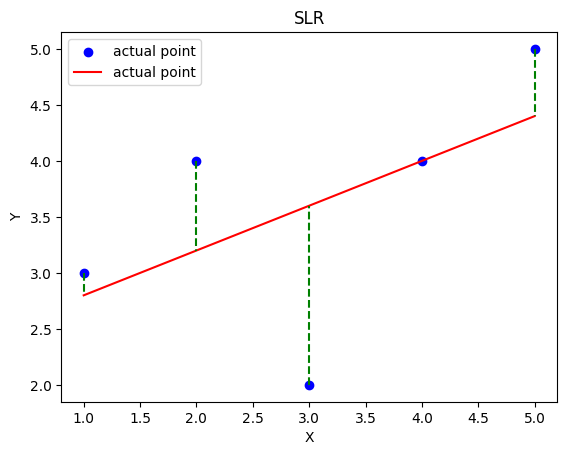

In [21]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([1, 2, 3, 4, 5])
Y = np.array([3, 4, 2, 4, 5])

x_m = np.mean(X)
y_m = np.mean(Y)

b1 = np.sum((X - x_m) * (Y - y_m)) / np.sum((X - x_m) ** 2)
b0 = y_m - b1 * x_m

y_pred = b0 + b1 * X

mse = np.mean((Y - y_pred)**2)

print(f"slope b0: {b0:.3f}")
print(f"coefficient b1: {b1:.3f}")
print(f"mse: {mse:.3f}")

plt.scatter(X,Y ,color = 'blue' ,label = 'actual point')
plt.plot(X,y_pred, color = 'red' ,label = 'actual point')

for i in range(len(X)):
    plt.vlines(X[i], Y[i], y_pred[i], colors = 'green', linestyles = 'dashed')
plt.xlabel('X')
plt.ylabel('Y')
plt.title("SLR")
plt.legend()
plt.show()

b0 slope:-1.556
b1:2.825
b2:-1.351
mse:0.151


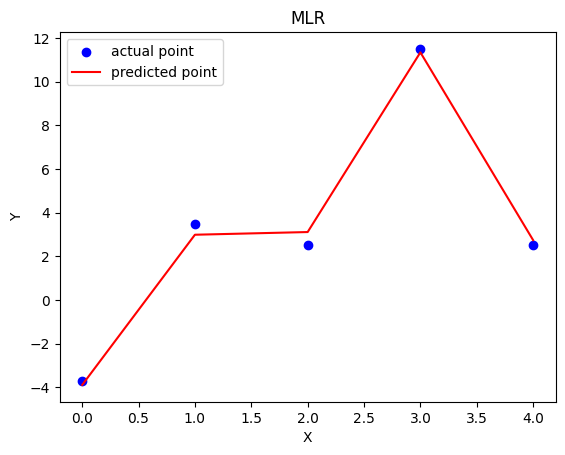

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Data
X1 = np.array([3, 4, 5, 6, 2])
X2 = np.array([8, 5, 7, 3, 1])
Y = np.array([-3.7, 3.5, 2.5, 11.5, 2.5])

X = np.column_stack((np.ones(len(X1)), X1, X2))

beta = np.linalg.inv(X.T @ X) @ X.T @ Y
b0,b1,b2 = beta

y_pred = X @ beta

mse = np.mean((Y - y_pred) ** 2)

print(f"b0 slope:{b0:.3f}")
print(f"b1:{b1:.3f}")
print(f"b2:{b2:.3f}")
print(f"mse:{mse:.3f}")

plt.scatter(range(len(Y)), Y, color = 'blue', label = 'actual point')
plt.plot(range(len(Y)), y_pred, color = 'red', label = 'predicted point')

plt.xlabel('X')
plt.ylabel('Y')
plt.title("MLR")
plt.legend()
plt.show()

Polinomial reggression

b0 intercept    = 0.517937
b1              = 0.556247
b2              = 1.674876
b3              = 0.818305
b4              = 1.203811
b5              = 0.169113
b6              = 0.404330
b7              = -0.406640
b8              = -0.233101
b9              = -0.147583


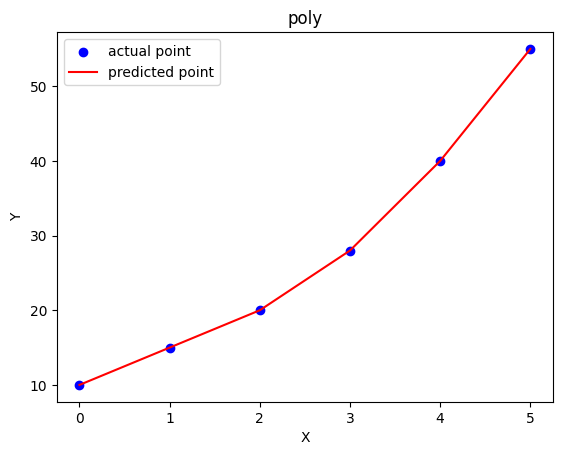

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# === Manual Sample Data ===
X1 = np.array([1, 2, 3, 4, 5, 6])
X2 = np.array([2, 5, 1, 6, 3, 7])  # make columns independent 
X3 = np.array([3, 1, 4, 2, 5, 6])
Y  = np.array([10, 15, 20, 28, 40, 55])

x_poly = np.column_stack((np.ones(len(X1)) ,X1,X2,X3,X1**2,X2**2,X3**2,X1*X2,X1*X3,X2*X3))

beta = np.linalg.pinv(x_poly.T @ x_poly) @ x_poly.T @ Y

y_pred = x_poly @ beta

coloums = ["b0 intercept", "b1", "b2", "b3","b4","b5","b6","b7","b8", "b9"]
print("Polinomial reggression\n")
for name, val in zip(coloums, beta):
    print(f"{name:15s} = {val:3f}")
plt.scatter(range(len(Y)), Y, color = 'blue', label = 'actual point')
plt.plot(range(len(Y)), y_pred, color = 'red', label = 'predicted point')

plt.xlabel('X')
plt.ylabel('Y')
plt.title("poly")
plt.legend()
plt.show()

logistic regg paramms:
bias b0 :-5.297
b1 (weight):    2.2322
predictions
X = 0.50 | Actual = 0.00 | prdicted = 0.00
X = 1.00 | Actual = 0.00 | prdicted = 0.00
X = 2.00 | Actual = 0.00 | prdicted = 0.00
X = 3.00 | Actual = 1.00 | prdicted = 1.00
X = 4.00 | Actual = 1.00 | prdicted = 1.00
X = 5.00 | Actual = 1.00 | prdicted = 1.00


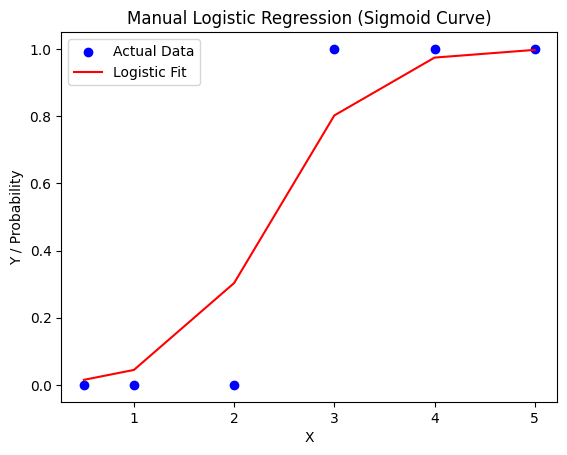

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# === Step 1: Create Sample Data ===
# Feature (X) and Labels (Y)
X = np.array([0.5, 1.0, 2.0, 3.0, 4.0, 5.0])
Y = np.array([0, 0, 0, 1, 1, 1])   # 0 = negative, 1 = positive class

X = X.reshape(-1, 1)

m = len(Y)
b0 = 0 # bais
b1 = 0 # weight
lr = 0.1
epo = 1000

def sigmoid(x):
    return 1 / (1 + np.exp(-z))

for i in range(epo):
    z = b0 + b1 * X.flatten()
    y_pred = sigmoid(z)

    db0 = np.sum(y_pred - Y) / m
    db1 = np.sum((y_pred - Y) * X.flatten()) / m

    b0 -= lr * db0
    b1 -= lr * db1

print("logistic regg paramms:")
print(f"bias b0 :{b0:.3f}")
print(f"b1 (weight):    {b1:.4f}")

y_pred_final = sigmoid(b0+b1* X.flatten())
y_class = (y_pred_final >= 0.5).astype(int)

print("predictions")
for xi, yi, yp in zip(X.flatten(), Y, y_class):
    print(f"X = {xi:.2f} | Actual = {yi:.2f} | prdicted = {yp:.2f}")

plt.scatter(X, Y, color='blue', label='Actual Data')
plt.plot(X, y_pred_final, color='red', label='Logistic Fit')
plt.xlabel("X")
plt.ylabel("Y / Probability")
plt.title("Manual Logistic Regression (Sigmoid Curve)")
plt.legend()
plt.show()

In [58]:
import numpy as np
from collections import Counter

# === Dataset ===
age = np.array([35, 22, 63, 59, 25, 37])
income = np.array([35, 50, 200, 170, 40, 50])
classes = np.array([0, 1, 0, 0, 1, 1])  # 0=No, 1=Yes

x = np.column_stack((age, income))
y= classes

def knn(xtrain, ytrain, test, k = 3):
    dist = np.linalg.norm(xtrain - test , axis = 1)
    kind = dist.argsort()[:k]
    klabel = ytrain[kind]
    pred = Counter(klabel).most_common(1)[0][0]
    return pred
test = np.array([30,40])
pred = knn(x,y,test, k=3)
print(f"test points income: {test[0]}K age: {test[1]}")
print(f"RESULT :{'yes' if pred == 1 else 'no'}")

test points income: 30K age: 40
RESULT :yes


Final Centroids:
 [[10 22]
 [ 4 18]]


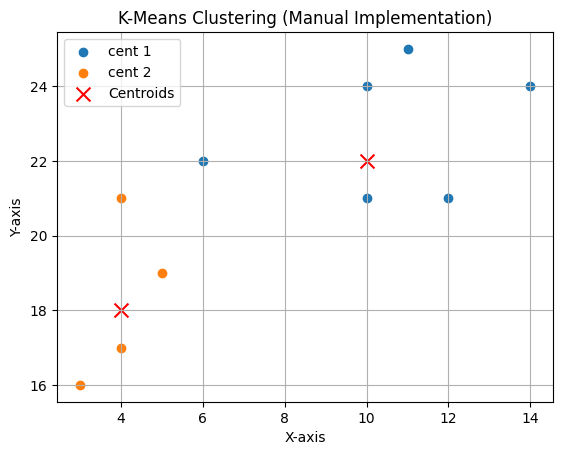

In [65]:
import numpy as np
import matplotlib.pyplot as plt

# === Step 1: Create sample data ===
x = np.array([4, 5, 10, 4, 3, 11, 14, 6, 10, 12])
y = np.array([21, 19, 24, 17, 16, 25, 24, 22, 21, 21])

X = np.column_stack((x,y))

k = 2

cen = X[np.random.choice(len(X), k, replace  = False)]

for _ in range(5):
    dist = [[np.linalg.norm(p-c) for c in cen] for p in X]
    label = np.argmin(dist, axis = 1)
    for i in range(k):
        cen[i] = X[label == i].mean(axis = 0)

print("Final Centroids:\n", cen)

for i in range(k):
    plt.scatter(X[label == i, 0], X[label == i, 1], label = f"cent {i + 1}")

plt.scatter(cen[:, 0], cen[:, 1], c='red', marker='x', s= 100, label="Centroids")

plt.title("K-Means Clustering (Manual Implementation)")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.legend()
plt.grid(True)
plt.show()